# Methodology: Monte Carlo Simulation of Cash Waqf-Linked Sukuk (CWLS) for MBG

This section explains the modeling framework, assumptions, simulation design, and sustainability metrics used to evaluate the feasibility of a perpetual waqf fund in financing the MBG program.

## 1. Research Design

This study employs a stochastic financial simulation approach using Monte Carlo methods to evaluate the sustainability of a perpetual waqf fund. The analysis is conducted over a 10-year horizon with 10,000 simulation paths. Each simulation generates random investment returns and food inflation rates, which determine the evolution of MBG costs and waqf fund performance. The primary objective is to estimate the probability that the waqf fund
can sustainably finance a target percentage of MBG total cost.

## 2. Model Framework

### 2.1 Investment Return Process

Annual investment returns follow a normal distribution:

r_t ~ N(μ_r, σ_r)

Where:
μ_r = expected return  
σ_r = return volatility  

### 2.2 Food Inflation Process

Food inflation follows:

π_t ~ N(μ_π, σ_π)

Inflation is truncated at a minimum positive level.

### 2.3 MBG Cost Function

Total MBG cost in year t:

C_t = N_t × c × d × Π(1 + π_i)

Where:
N_t = number of recipients  
c = cost per meal  
d = school days per year  
π_i = inflation rate  

### 2.4 Waqf Fund Dynamics

Let W_t denote fund value:

W_{t+1} = W_t + r_t W_t − Spending_t

Spending is defined as:

Spending_t = min(r_t W_t, α C_t)

Where: α = target coverage rate.

## 3. Sustainability Metrics

Two sustainability definitions are used:

1. Yearly Sustainability Probability:

P(r_t W_t ≥ α C_t)

This measures the probability that the fund can cover the target share in a given year.

2. Full-Horizon Sustainability Probability:

P(r_t W_t ≥ α C_t for all t = 1,...,T)

This measures the probability that the fund remains sustainable for the entire 10-year horizon.

The second metric is stricter and reflects long-term viability.

## 4. Parameter Assumptions

The model uses the following baseline assumptions:

- Expected return: 6.4%
- Return volatility: 0.5%
- Food inflation: 4–5%
- Cost per meal: Rp 15,000
- School days: 261 per year
- Recipients: Growth from 20M to 82.9M (Year 5) and Year 6 until Year 10 => 82.9M students for each year

In [19]:
set.seed(123)

library(ggplot2)
library(dplyr)
library(patchwork)
library(scales)
library(tidyr)

# =========================
# PARAMETERS (match method_revised.R)
# =========================
years <- 10
n_sim <- 10000

mean_yield <- 0.064
sd_yield   <- 0.005

mean_infl <- 0.045
sd_infl   <- 0.005

cost_per_meal <- 15000
days_per_year <- 261

recipients <- numeric(years)
recipients[1] <- 20e6
for (t in 2:years) {
  if (t <= 5) recipients[t] <- recipients[t - 1] + (82.9e6 - 20e6) / 4
  else        recipients[t] <- 82.9e6
}

## 5. Simulation Procedure

For each Monte Carlo iteration:

1. Draw random return and inflation paths.
2. Compute cumulative inflation.
3. Calculate MBG cost for each year.
4. Compute waqf yield income.
5. Determine coverage ratio.
6. Update fund value dynamically.
7. Record sustainability outcomes.

This process is repeated 10,000 times.

In [20]:
# =========================
# SIMULATION FUNCTION
# =========================
run_waqf_simulation <- function(principal, coverage_target) {
  coverage_matrix <- matrix(0, n_sim, years)

  for (sim in 1:n_sim) {
    yield     <- rnorm(years, mean_yield, sd_yield)
    inflation <- pmax(rnorm(years, mean_infl, sd_infl), 0.01)

    inflation_factor <- 1
    fund <- principal
      
    for (t in 1:years) {
        inflation_factor <- inflation_factor * (1 + inflation[t])
        mbg_cost_t <- recipients[t] * cost_per_meal * days_per_year * inflation_factor
        
        yield_income_t <- fund * yield[t]
        
        target_spending <- coverage_target * mbg_cost_t
        
        actual_spending <- yield_income_t
        
        coverage_fraction <- actual_spending / mbg_cost_t
        coverage_matrix[sim, t] <- coverage_fraction
        
        fund <- fund + yield_income_t - actual_spending
        }
    }

  success <- coverage_matrix >= coverage_target

  list(
    prob_by_year    = colMeans(success),
    prob_sustained  = mean(apply(success, 1, all)),
    prob_year       = mean(success),
    avg_coverage    = colMeans(coverage_matrix),
    coverage_matrix = coverage_matrix
  )
}

## 6. Scenario Analysis

Two principal scenarios are evaluated:

- Rp 200 trillion
- Rp 400 trillion

These represent moderate and large-scale waqf fund formations. The objective is to compare sustainability probabilities across fund sizes.

In [21]:
# =========================
# RUN ALL SCENARIOS
# =========================

scenarios <- list(
  "200T" = list(principal = 200e12, target = 0.025),
  "400T" = list(principal = 400e12, target = 0.050)
)
# =========================
# HEADER
# =========================
cat("================================================================\n")
cat("  MONTE CARLO: Dana Abadi Wakaf untuk MBG\n")
cat("================================================================\n")
cat(sprintf("  N = %s simulations | %d years | Yield ~ N(%.1f%%, %.1f%%)\n",
            format(n_sim, big.mark = ","), years,
            mean_yield * 100, sd_yield * 100))
cat(sprintf("  Inflasi ~ N(%.1f%%, %.1f%%) | Cost/meal Rp %s | %d days/yr\n",
            mean_infl * 100, sd_infl * 100,
            format(cost_per_meal, big.mark = ","), days_per_year))
cat("================================================================\n\n")

# =========================
# RUN PER-SCENARIO
# =========================
for (nm in names(scenarios)) {
  sc  <- scenarios[[nm]]
  res <- run_waqf_simulation(sc$principal, sc$target)

  cat(sprintf("--- Skenario %s (Principal Rp %s | Target %.1f%%) ---\n",
              nm, nm, sc$target * 100))
  cat("Probability that all years are sustainable:",
      round(res$prob_sustained * 100, 2), "%\n")
  cat("Probability that a given year is sustainable:",
      round(res$prob_year * 100, 2), "%\n")
  cat("  Per-year:\n")
  for (t in 1:years) {
    cat(sprintf("    Year %2d: P(>=%.1f%%) = %5.1f%%  |  Avg coverage = %.2f%%\n",
                t, sc$target * 100,
                res$prob_by_year[t] * 100,
                res$avg_coverage[t] * 100))
  }
  cat("\n")
}

  MONTE CARLO: Dana Abadi Wakaf untuk MBG
  N = 10,000 simulations | 10 years | Yield ~ N(6.4%, 0.5%)
  Inflasi ~ N(4.5%, 0.5%) | Cost/meal Rp 15,000 | 261 days/yr

--- Skenario 200T (Principal Rp 200T | Target 2.5%) ---
Probability that all years are sustainable: 37.7 %
Probability that a given year is sustainable: 91.75 %
  Per-year:
    Year  1: P(>=2.5%) = 100.0%  |  Avg coverage = 15.64%
    Year  2: P(>=2.5%) = 100.0%  |  Avg coverage = 8.39%
    Year  3: P(>=2.5%) = 100.0%  |  Avg coverage = 5.57%
    Year  4: P(>=2.5%) = 100.0%  |  Avg coverage = 4.08%
    Year  5: P(>=2.5%) =  99.6%  |  Avg coverage = 3.16%
    Year  6: P(>=2.5%) =  98.7%  |  Avg coverage = 3.03%
    Year  7: P(>=2.5%) =  95.6%  |  Avg coverage = 2.90%
    Year  8: P(>=2.5%) =  89.5%  |  Avg coverage = 2.78%
    Year  9: P(>=2.5%) =  76.5%  |  Avg coverage = 2.65%
    Year 10: P(>=2.5%) =  57.7%  |  Avg coverage = 2.54%

--- Skenario 400T (Principal Rp 400T | Target 5.0%) ---
Probability that all years are sus

## 7. Coverage Optimization (Sweet Spot Analysis)

To determine the maximum feasible coverage level, a grid search approach is used. Coverage targets ranging from 0.5% to 20% are tested. For each level, the full-horizon sustainability probability is calculated. The “sweet spot” is defined as the highest coverage rate that achieves at least:

- 90% sustainability probability
- 80% sustainability probability
- 50% sustainability probability

In [22]:
# =========================
# SWEET SPOT COVERAGE
# =========================
cat("================================================================\n")
cat("  SWEET SPOT COVERAGE: MBG FUND SUSTAINABILITY\n")
cat("================================================================\n")

sweep_targets <- seq(0.005, 0.20, by = 0.001)

for (nm in names(scenarios)) {
  sc  <- scenarios[[nm]]
  res <- run_waqf_simulation(sc$principal, sc$target)
  cov_mat <- res$coverage_matrix

  probs <- vapply(sweep_targets, function(tgt) {
    mean(apply(cov_mat >= tgt, 1, all))
  }, numeric(1))

  find_max_coverage <- function(prob_thresh) {
    hits <- which(probs >= prob_thresh)
    if (length(hits) == 0) return(NA_real_)
    sweep_targets[max(hits)]
  }

  c99 <- find_max_coverage(0.99)
  c95 <- find_max_coverage(0.95)
  c90 <- find_max_coverage(0.90)
  c80 <- find_max_coverage(0.80)
  c50 <- find_max_coverage(0.50)

  cat(sprintf("\n  Skenario %s (Principal = Rp %s)\n", nm,
              format(sc$principal, big.mark = ",", scientific = FALSE)))
  cat("    Coverage for 99% sustainability :",
      if (is.na(c99)) "N/A" else paste0(c99 * 100, "%"), "\n")
  cat("    Coverage for 95% sustainability :",
      if (is.na(c95)) "N/A" else paste0(c95 * 100, "%"), "\n")
  cat("    Coverage for 90% sustainability :",
      if (is.na(c90)) "N/A" else paste0(c90 * 100, "%"), "\n")
  cat("    Coverage for 80% sustainability :",
      if (is.na(c80)) "N/A" else paste0(c80 * 100, "%"), "\n")
  cat("    Coverage for 50% sustainability :",
      if (is.na(c50)) "N/A" else paste0(c50 * 100, "%"), "\n")
}

cat("\n================================================================\n")


  SWEET SPOT COVERAGE: MBG FUND SUSTAINABILITY

  Skenario 200T (Principal = Rp 200,000,000,000,000)
    Coverage for 99% sustainability : 2% 
    Coverage for 95% sustainability : 2.1% 
    Coverage for 90% sustainability : 2.2% 
    Coverage for 80% sustainability : 2.3% 
    Coverage for 50% sustainability : 2.4% 

  Skenario 400T (Principal = Rp 400,000,000,000,000)
    Coverage for 99% sustainability : 4.1% 
    Coverage for 95% sustainability : 4.3% 
    Coverage for 90% sustainability : 4.4% 
    Coverage for 80% sustainability : 4.6% 
    Coverage for 50% sustainability : 4.8% 



## 8. Model Assumptions and Limitations

This model is developed under the following key assumptions:

- Investment returns (yield) and food inflation follow normal distributions, characterized by constant means and standard deviations over time.

- The waqf fund evolves dynamically according to a financial accumulation mechanism, where the fund balance in each year is updated based on realized returns and actual spending.

- Spending from the fund is constrained by the available yield, consistent with a perpetual (principal-preserving) waqf structure.

Given these assumptions, the simulation results should be interpreted as baseline probabilistic estimates under normal economic conditions rather than precise forecasts. Extreme market shocks, structural breaks, policy changes, or governance frictions are not explicitly modeled.

## 9. Visualization

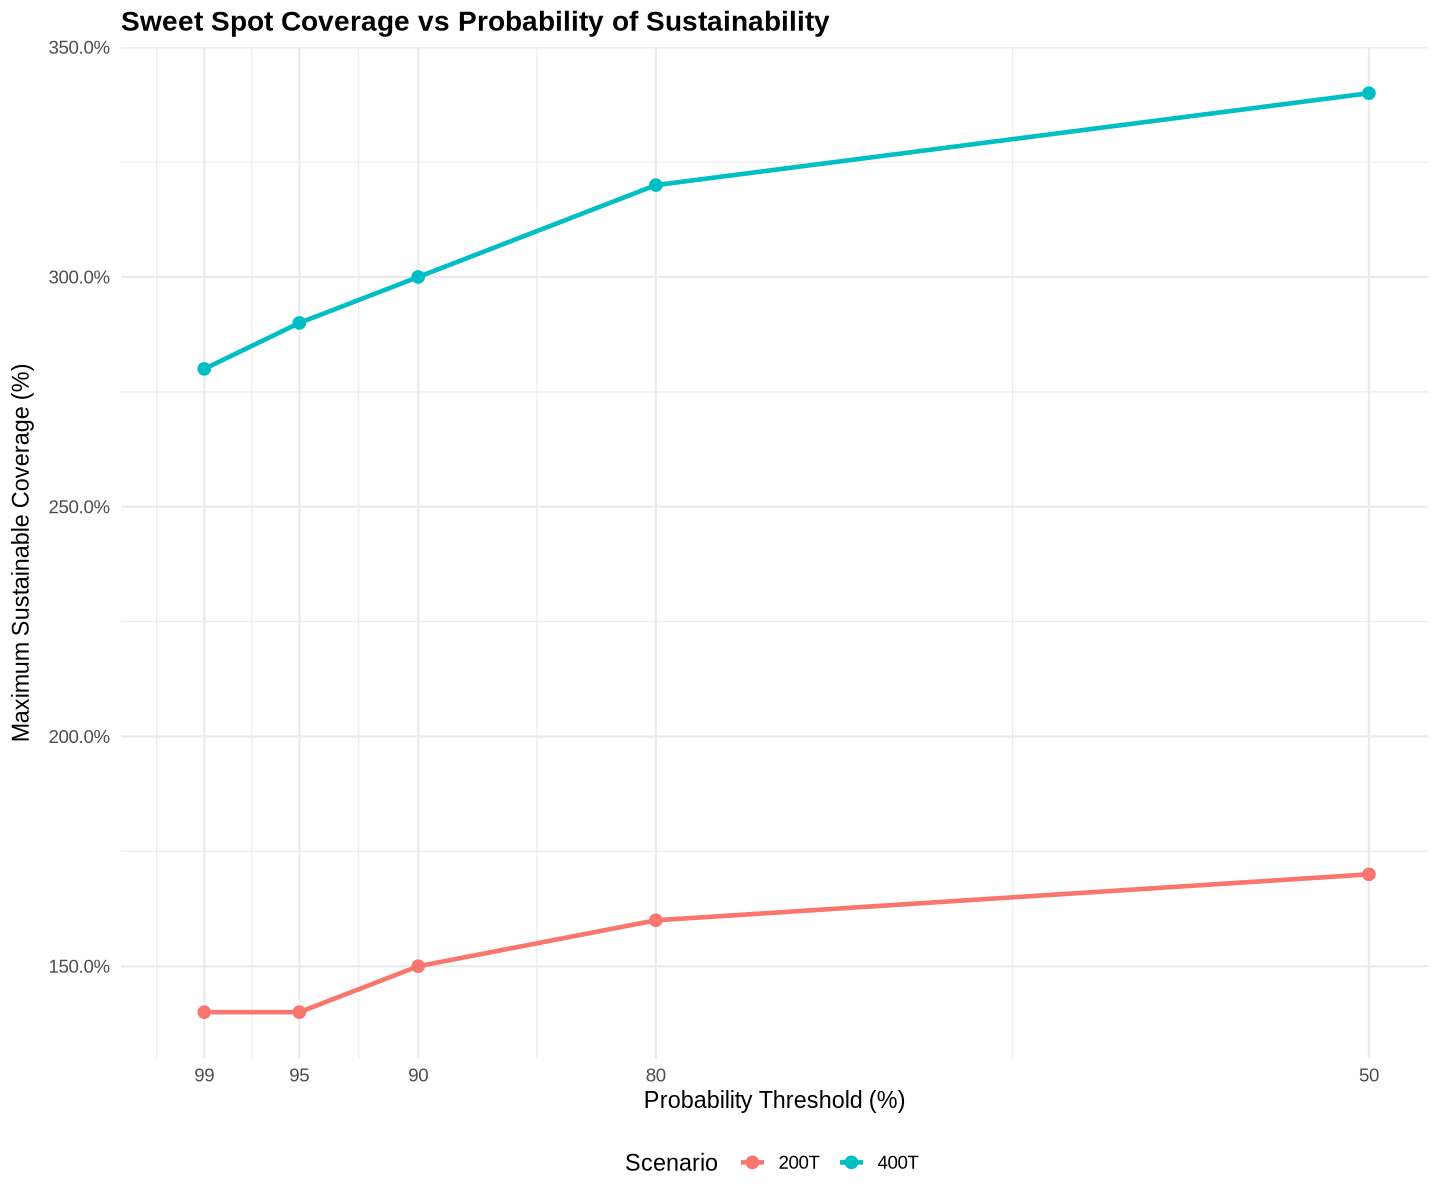

In [25]:
# ----------------------
# 1️⃣ Sweet Spot Plot
# ----------------------
sweet_spot_df <- data.frame(
  Scenario = rep(names(results), each = length(prob_thresholds)),
  Probability = rep(prob_thresholds, times = length(results)),
  Coverage = c(find_sweet_spots(results[["200T"]]),
               find_sweet_spots(results[["400T"]]))
)

p1 <- ggplot(sweet_spot_df, aes(x = Probability*100, y = Coverage*100, color = Scenario)) +
  geom_line(size=1.3) +
  geom_point(size=3) +
  scale_x_reverse(limits=c(100,50), breaks=c(99,95,90,80,50)) +
  scale_y_continuous(labels = percent_format(accuracy = 0.1)) +
  labs(title = "Sweet Spot Coverage vs Probability of Sustainability",
       x = "Probability Threshold (%)",
       y = "Maximum Sustainable Coverage (%)",
       color = "Scenario") +
  theme_minimal(base_size = 14) +
  theme(legend.position="bottom", plot.title = element_text(face="bold"))
p1

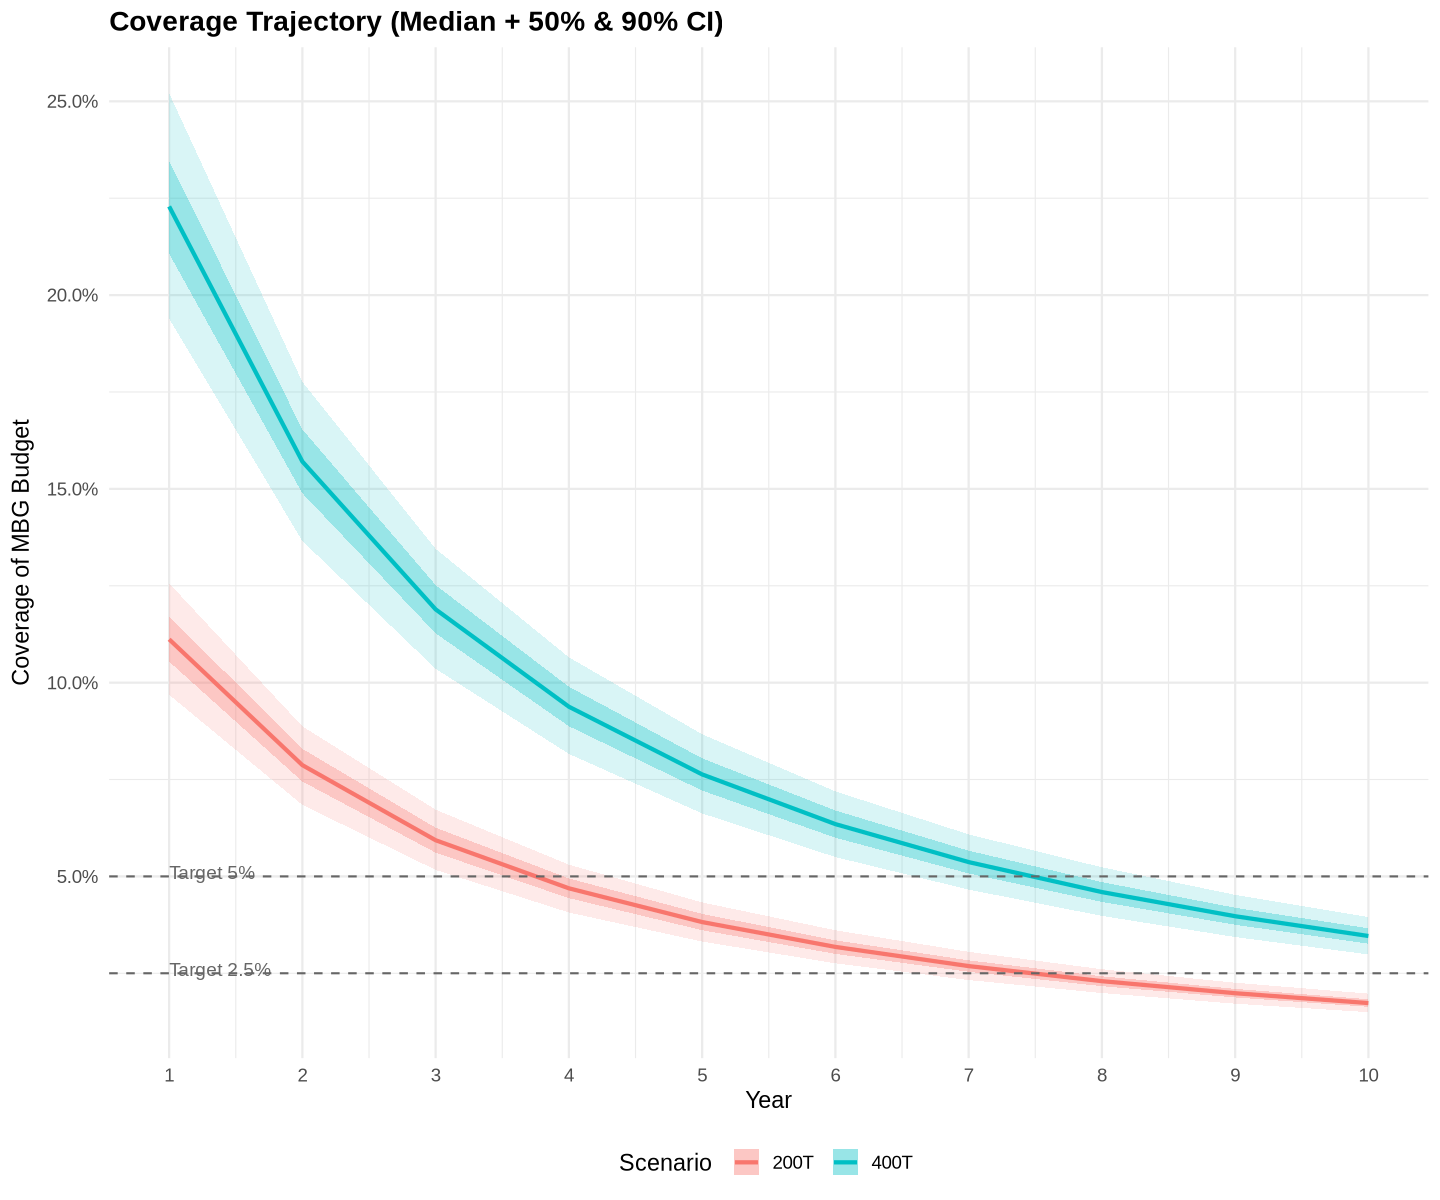

In [26]:
# ----------------------
# FAN DATA FOR COVERAGE TRAJECTORY
# ----------------------
fan_data <- do.call(rbind, lapply(names(results), function(nm){
  cm <- results[[nm]]
  sc <- scenarios[[nm]]
  data.frame(
    scenario = nm,
    target_pct = sc$target*100,
    year = 1:years,
    median = apply(cm,2,median),
    p05    = apply(cm,2,quantile,0.05),
    p25    = apply(cm,2,quantile,0.25),
    p75    = apply(cm,2,quantile,0.75),
    p95    = apply(cm,2,quantile,0.95)
  )
}))

# ----------------------
# 2️⃣ Coverage Trajectory (Fan Plot)
# ----------------------
p2 <- ggplot(fan_data, aes(x = year)) +
  geom_ribbon(aes(ymin = p05, ymax = p95, fill = scenario), alpha = 0.15) +
  geom_ribbon(aes(ymin = p25, ymax = p75, fill = scenario), alpha = 0.3) +
  geom_line(aes(y = median, color = scenario), linewidth = 1.2) +
  geom_hline(yintercept = c(0.025, 0.05), linetype = "dashed", color = "grey40", linewidth = 0.6) +
  annotate("text", x = 1, y = 0.026, label = "Target 2.5%", hjust = 0, size = 4, color="grey40") +
  annotate("text", x = 1, y = 0.051, label = "Target 5%", hjust = 0, size = 4, color="grey40") +
  scale_x_continuous(breaks = 1:years) +
  scale_y_continuous(labels = percent_format(accuracy = 0.1)) +
  labs(title = "Coverage Trajectory (Median + 50% & 90% CI)",
       x = "Year",
       y = "Coverage of MBG Budget",
       fill = "Scenario",
       color = "Scenario") +
  theme_minimal(base_size = 14) +
  theme(legend.position="bottom", plot.title = element_text(face="bold"))
p2

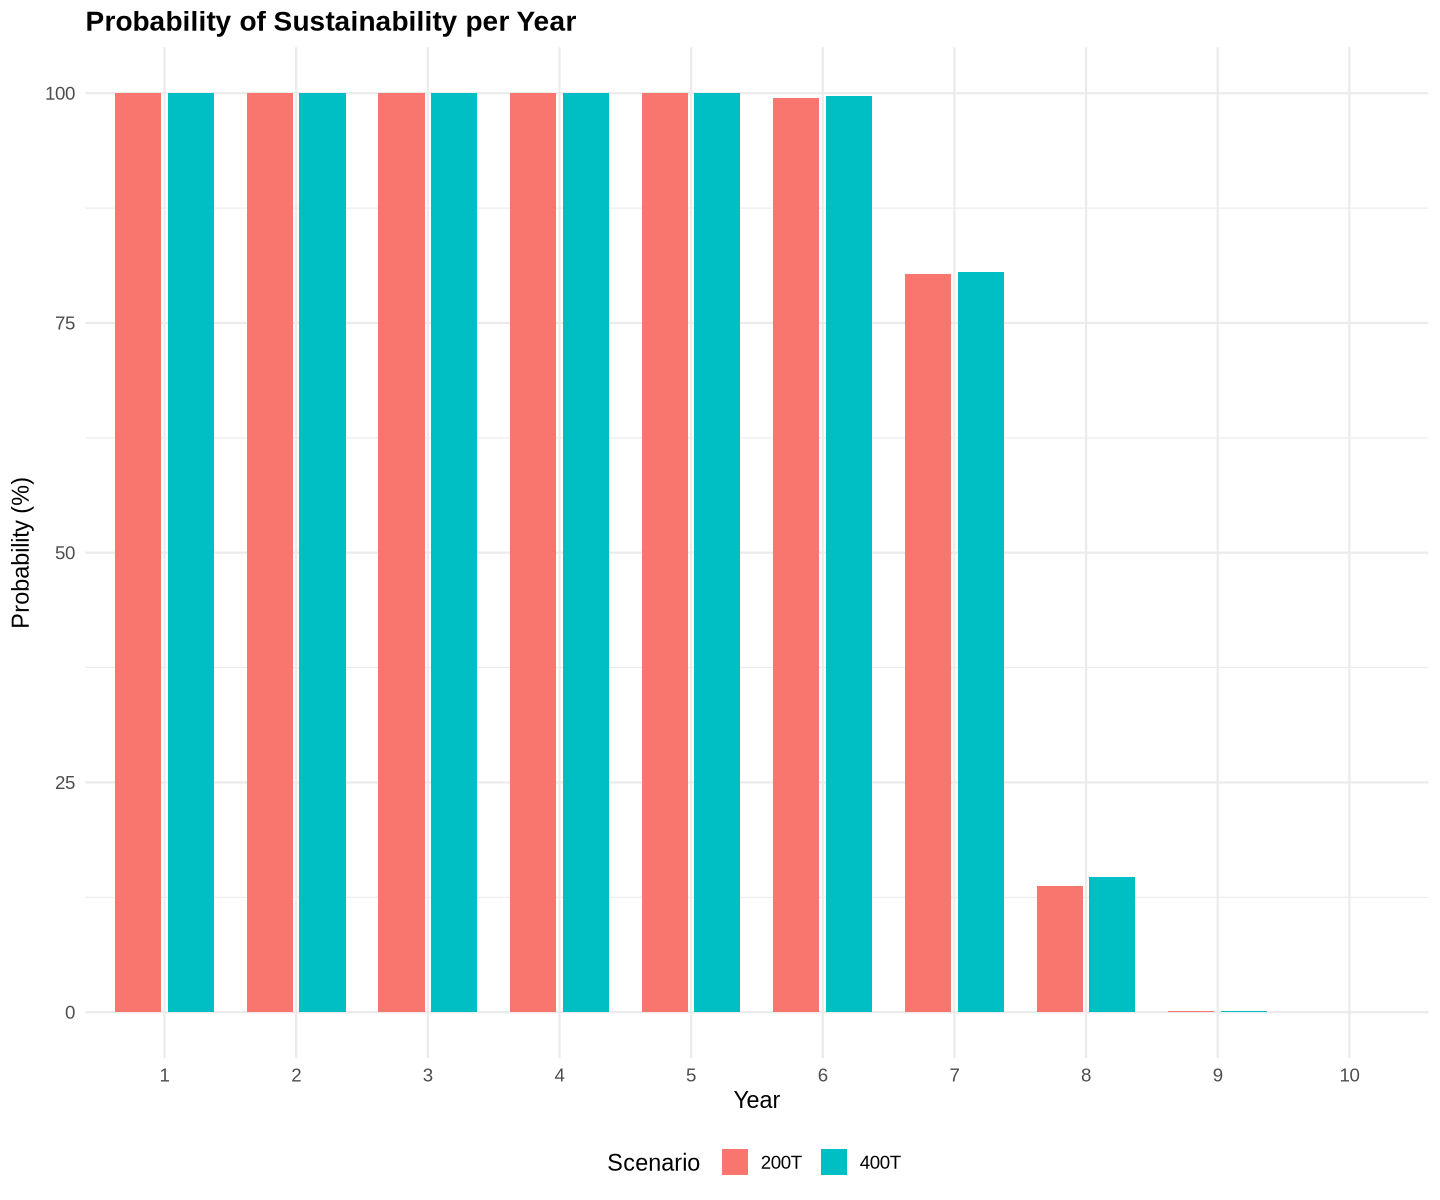

In [27]:
# ----------------------
# 3️⃣ Probability of Sustainability per Year (Bar Chart)
# ----------------------
prob_sustain_df <- data.frame(
  Year = rep(1:years, times = length(results)),
  Scenario = rep(names(results), each = years),
  Prob = c(colMeans(results[["200T"]] >= 0.025),
           colMeans(results[["400T"]] >= 0.05))
)

p3 <- ggplot(prob_sustain_df, aes(x = factor(Year), y = Prob*100, fill = Scenario)) +
  geom_bar(stat="identity", position = position_dodge(width=0.8), width=0.7) +
  labs(title = "Probability of Sustainability per Year",
       x = "Year",
       y = "Probability (%)",
       fill = "Scenario") +
  theme_minimal(base_size = 14) +
  theme(legend.position="bottom", plot.title = element_text(face="bold"))
p3

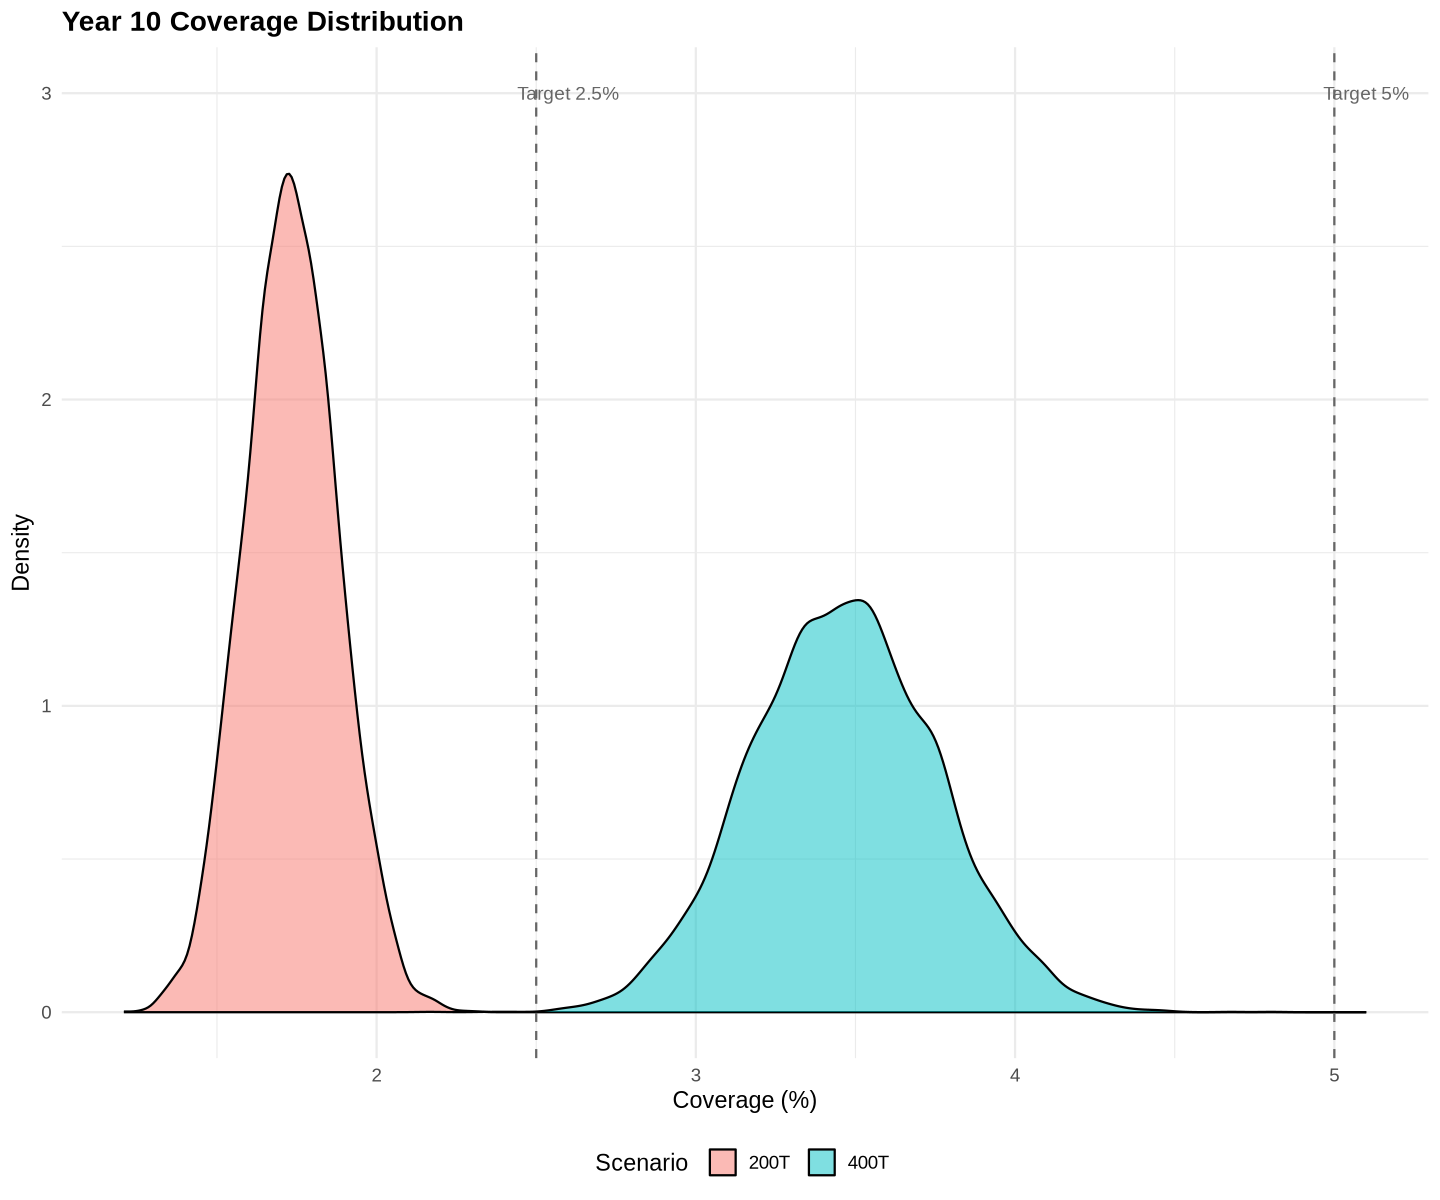

In [28]:
# ----------------------
# 4️⃣ Year 10 Coverage Distribution (Density Plot)
# ----------------------
year10_df <- data.frame(
  Coverage = c(results[["200T"]][,10], results[["400T"]][,10]),
  Scenario = rep(names(results), each = nrow(results[["200T"]]))
)

p4 <- ggplot(year10_df, aes(x = Coverage*100, fill = Scenario)) +
  geom_density(alpha = 0.5) +
  geom_vline(xintercept = c(2.5, 5), linetype="dashed", color="grey40") +
  annotate("text", x = 2.6, y = 3, label="Target 2.5%", color="grey40", size=4) +
  annotate("text", x = 5.1, y = 3, label="Target 5%", color="grey40", size=4) +
  labs(title = "Year 10 Coverage Distribution",
       x = "Coverage (%)",
       y = "Density",
       fill = "Scenario") +
  theme_minimal(base_size = 14) +
  theme(legend.position="bottom", plot.title = element_text(face="bold"))
p4

In [29]:
# Save Sweet Spot Plot
ggsave("sweet_spot_plot.png", plot = p1, width = 8, height = 6, dpi = 300)

# Save Coverage Trajectory
ggsave("coverage_trajectory.png", plot = p2, width = 8, height = 6, dpi = 300)

# Save Probability Sustainability
ggsave("probability_sustainability.png", plot = p3, width = 8, height = 6, dpi = 300)

# Save Year 10 Coverage Distribution
ggsave("year10_density.png", plot = p4, width = 8, height = 6, dpi = 300)